In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("All India Consumer Price Index.csv")
print(df.head())

        Sector  Year  ... Miscellaneous  General index
0        Rural  2013  ...         104.0          105.1
1        Urban  2013  ...         103.7          104.0
2  Rural+Urban  2013  ...         103.9          104.6
3        Rural  2013  ...         104.4          105.8
4        Urban  2013  ...         104.3          104.7

[5 rows x 30 columns]


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               365 non-null    object 
 1   Year                                 365 non-null    int64  
 2   Month                                365 non-null    object 
 3   Cereals and products                 362 non-null    float64
 4   Meat and fish                        359 non-null    float64
 5   Egg                                  362 non-null    float64
 6   Milk and products                    362 non-null    float64
 7   Oils and fats                        362 non-null    float64
 8   Fruits                               362 non-null    float64
 9   Vegetables                           362 non-null    float64
 10  Pulses and products                  362 non-null    float64
 11  Sugar and Confectionery         

In [3]:
print(df.isnull())

     Sector   Year  ...  Miscellaneous  General index
0     False  False  ...          False          False
1     False  False  ...          False          False
2     False  False  ...          False          False
3     False  False  ...          False          False
4     False  False  ...          False          False
..      ...    ...  ...            ...            ...
360   False  False  ...          False          False
361   False  False  ...          False          False
362   False  False  ...          False          False
363   False  False  ...          False          False
364   False  False  ...          False          False

[365 rows x 30 columns]


In [4]:
print(df.isnull().sum())

Sector                                   0
Year                                     0
Month                                    0
Cereals and products                     3
Meat and fish                            6
Egg                                      3
Milk and products                        3
Oils and fats                            3
Fruits                                   3
Vegetables                               3
Pulses and products                      3
Sugar and Confectionery                  3
Spices                                   3
Non-alcoholic beverages                  3
Prepared meals, snacks, sweets etc.      6
Food and beverages                       3
Pan, tobacco and intoxicants             6
Clothing                                 6
Footwear                                 6
Clothing and footwear                    6
Housing                                122
Fuel and light                           3
Household goods and services             6
Health     

In [5]:
cpi_columns = ["Cereals and products","Meat and fish","Egg","Milk and products","Oils and fats","Fruits","Vegetables","Pulses and products","Sugar and Confectionery","Spices","Non-alcoholic beverages","Prepared meals, snacks, sweets etc.","Food and beverages","Pan, tobacco and intoxicants","Clothing","Footwear","Clothing and footwear","Housing","Fuel and light","Household goods and services","Health","Transport and communication","Recreation and amusement","Education","Personal care and effects","Miscellaneous","General index"]
for col in cpi_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print("CPI columns converted to numeric successfully.")

CPI columns converted to numeric successfully.


In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

Sector                                 0
Year                                   0
Month                                  0
Cereals and products                   0
Meat and fish                          0
Egg                                    0
Milk and products                      0
Oils and fats                          0
Fruits                                 0
Vegetables                             0
Pulses and products                    0
Sugar and Confectionery                0
Spices                                 0
Non-alcoholic beverages                0
Prepared meals, snacks, sweets etc.    0
Food and beverages                     0
Pan, tobacco and intoxicants           0
Clothing                               0
Footwear                               0
Clothing and footwear                  0
Housing                                0
Fuel and light                         0
Household goods and services           0
Health                                 0
Transport and co

In [7]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate Rows After Removing:", df.duplicated().sum())

Duplicate Rows: 0
Duplicate Rows After Removing: 0


In [8]:
outlier_counts = {}
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_counts[col] = int(((df[col] < lower_bound) | (df[col] > upper_bound)).sum())
print(outlier_counts)

{'Year': 0, 'Cereals and products': 0, 'Meat and fish': 0, 'Egg': 0, 'Milk and products': 0, 'Oils and fats': 50, 'Fruits': 0, 'Vegetables': 8, 'Pulses and products': 0, 'Sugar and Confectionery': 0, 'Spices': 4, 'Non-alcoholic beverages': 6, 'Prepared meals, snacks, sweets etc.': 0, 'Food and beverages': 0, 'Pan, tobacco and intoxicants': 0, 'Clothing': 0, 'Footwear': 6, 'Clothing and footwear': 0, 'Housing': 0, 'Fuel and light': 0, 'Household goods and services': 0, 'Health': 0, 'Transport and communication': 0, 'Recreation and amusement': 0, 'Education': 0, 'Personal care and effects': 0, 'Miscellaneous': 0, 'General index': 0}


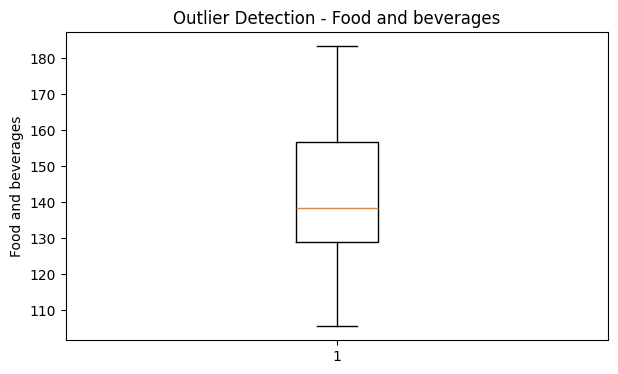

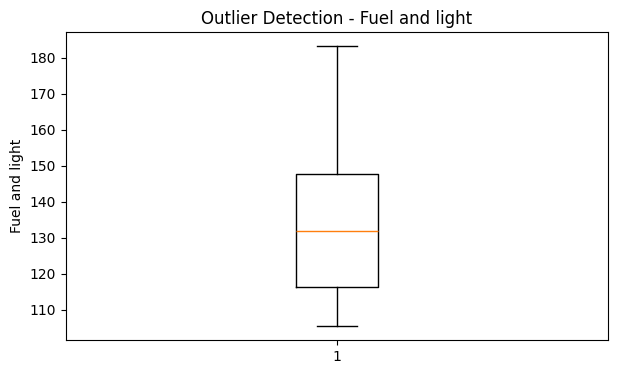

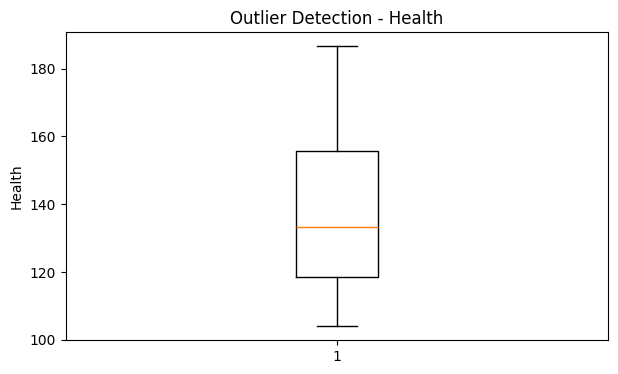

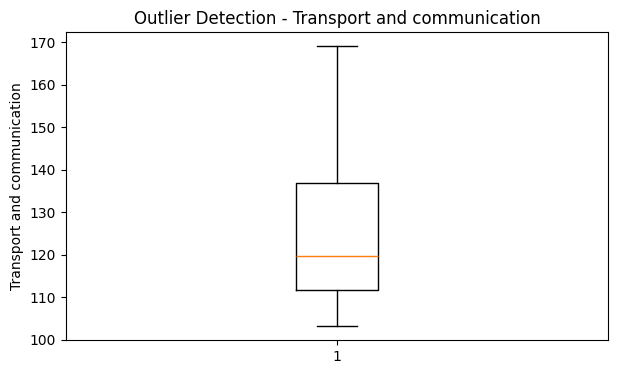

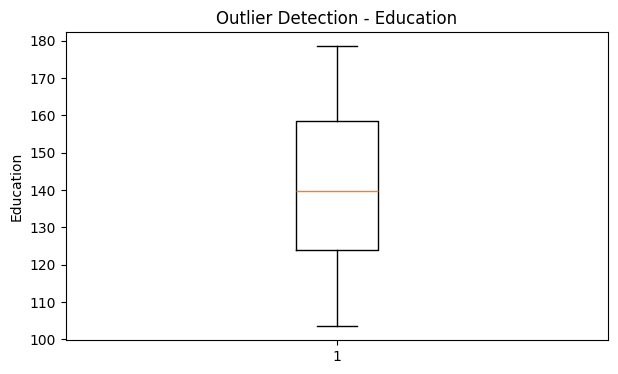

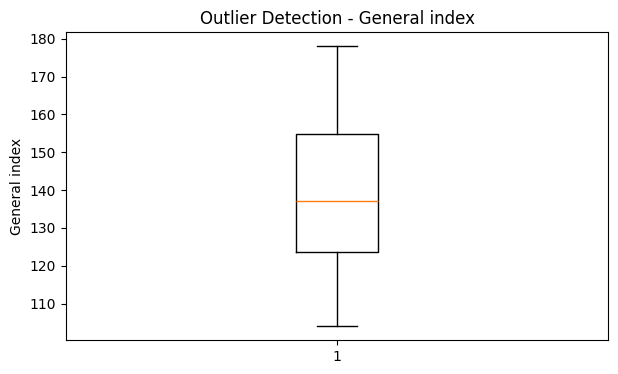

In [9]:
visualization_columns = ["Food and beverages","Fuel and light","Health","Transport and communication","Education","General index"]
for col in visualization_columns:
    plt.figure(figsize=(7,4))
    plt.boxplot(df[col].dropna())
    plt.title("Outlier Detection - " + col)
    plt.ylabel(col)
    plt.show()

In [10]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(",", "")
print(df.columns)

Index(['sector', 'year', 'month', 'cereals_and_products', 'meat_and_fish',
       'egg', 'milk_and_products', 'oils_and_fats', 'fruits', 'vegetables',
       'pulses_and_products', 'sugar_and_confectionery', 'spices',
       'non-alcoholic_beverages', 'prepared_meals_snacks_sweets_etc.',
       'food_and_beverages', 'pan_tobacco_and_intoxicants', 'clothing',
       'footwear', 'clothing_and_footwear', 'housing', 'fuel_and_light',
       'household_goods_and_services', 'health', 'transport_and_communication',
       'recreation_and_amusement', 'education', 'personal_care_and_effects',
       'miscellaneous', 'general_index'],
      dtype='object')


In [11]:
scaler = MinMaxScaler()
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
print(df.head())

        sector  year  ... miscellaneous  general_index
0        Rural   0.0  ...      0.004043       0.014865
1        Urban   0.0  ...      0.000000       0.000000
2  Rural+Urban   0.0  ...      0.002695       0.008108
3        Rural   0.0  ...      0.009434       0.024324
4        Urban   0.0  ...      0.008086       0.009459

[5 rows x 30 columns]


In [12]:
df.to_excel("cleaned_consumer_price_index.xlsx", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [13]:
print("======================================")
print("Experiment 3 Completed Successfully")
print("Missing Values Handled")
print("Duplicate Records Removed")
print("Outliers Detected")
print("Column Names Cleaned")
print("Min-Max Normalization Completed")
print("======================================")

Experiment 3 Completed Successfully
Missing Values Handled
Duplicate Records Removed
Outliers Detected
Column Names Cleaned
Min-Max Normalization Completed
